In [ ]:
# Data have been loaded via drag-and-drop

**Data Import and Cleaning:**

In [ ]:
import pandas as pd

airplane_crashes = pd.read_csv('/content/Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv', encoding='ISO-8859-1')
airplane_crashes.head()

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


In [ ]:
print(len(airplane_crashes))
airplane_crashes.isnull().sum()

4998


,0
Date,0
Time,1512
Location,4
Operator,10
Flight #,3669
Route,777
AC Type,15
Registration,274
cn/ln,668
Aboard,18


In [ ]:
# Find percentage of missing values
missing_percent = (airplane_crashes.isnull().sum() / len(airplane_crashes)) * 100

# Display columns with the pourcentage of missing values
print(missing_percent.sort_values(ascending=False))

Flight #                 73.409364
Time                     30.252101
Route                    15.546218
cn/ln                    13.365346
Registration              5.482193
Fatalities Passangers     4.841937
Fatalities Crew           4.821929
Aboard Passangers         4.581833
Aboard Crew               4.521809
Summary                   1.280512
Ground                    0.840336
Aboard                    0.360144
AC Type                   0.300120
Operator                  0.200080
Fatalities                0.160064
Location                  0.080032
Date                      0.000000
dtype: float64


In [ ]:
# 'Flight #' has more than 50% (73%) of missing values
airplane_crashes.drop(columns=["Flight #"], inplace=True)

In [ ]:
# Some columns have few missing values
airplane_crashes.dropna(subset=["Location", "Operator", "AC Type", "Aboard", "Fatalities", "Ground"], inplace=True)

In [ ]:
# Categorical missing values
airplane_crashes.fillna({
    "Route": "Unknown",
    "cn/ln" : "Unknown",
    "Registration": "Unknown",
    "Summary": "Unknown"
}, inplace=True)

In [ ]:
# Numerical missing values (fill with median)
num_cols = ["Fatalities Passangers", "Fatalities Crew", "Aboard Passangers", "Aboard Crew"]

for col in num_cols:
    airplane_crashes.loc[:, col] = airplane_crashes[col].fillna(airplane_crashes[col].median())

In [ ]:
print(airplane_crashes.dtypes["Date"])


object


In [ ]:
# Transform "Date" into format 'Date'
airplane_crashes["Date"] = pd.to_datetime(airplane_crashes["Date"])
print(airplane_crashes.dtypes["Date"])

datetime64[ns]


In [ ]:
airplane_crashes["Time"] = airplane_crashes["Time"].fillna("00:00")

In [ ]:
airplane_crashes.isnull().sum()

,0
Date,0
Time,0
Location,0
Operator,0
Route,0
AC Type,0
Registration,0
cn/ln,0
Aboard,0
Aboard Passangers,0


**Exploratory Data Analysis:**

- Use Pandas to explore basic statistics such as the number of crashes, fatalities, and survival rates.

In [ ]:
# Number of craches
total_crashes = len(airplane_crashes)
print("Total number of crashes:", total_crashes)

Total number of crashes: 4929


In [ ]:
# Number of fatalities
total_fatalities = airplane_crashes["Fatalities"].sum()
print("Total number of fatalities:", total_fatalities)

Total number of fatalities: 111051.0


In [ ]:
# Survival rate
airplane_crashes["Survivors"] = airplane_crashes["Aboard"] - airplane_crashes["Fatalities"]
airplane_crashes["Survival Rate"] = (airplane_crashes["Survivors"] / airplane_crashes["Aboard"]) * 100

average_survival_rate = airplane_crashes["Survival Rate"].mean()
print(f"Average Survival Rate: {average_survival_rate:.2f}%")

Average Survival Rate: 18.20%


- Analyze the frequency of crashes over time to identify any trends.

In [ ]:
# Extract the year
airplane_crashes["Year"] = airplane_crashes["Date"].dt.year

In [ ]:
crashes_per_year = airplane_crashes.groupby("Year").size().reset_index(name="Crash Count")

# Display the first few years
print(crashes_per_year.head())

   Year  Crash Count
0  1908            1
1  1912            1
2  1913            3
3  1915            2
4  1916            5


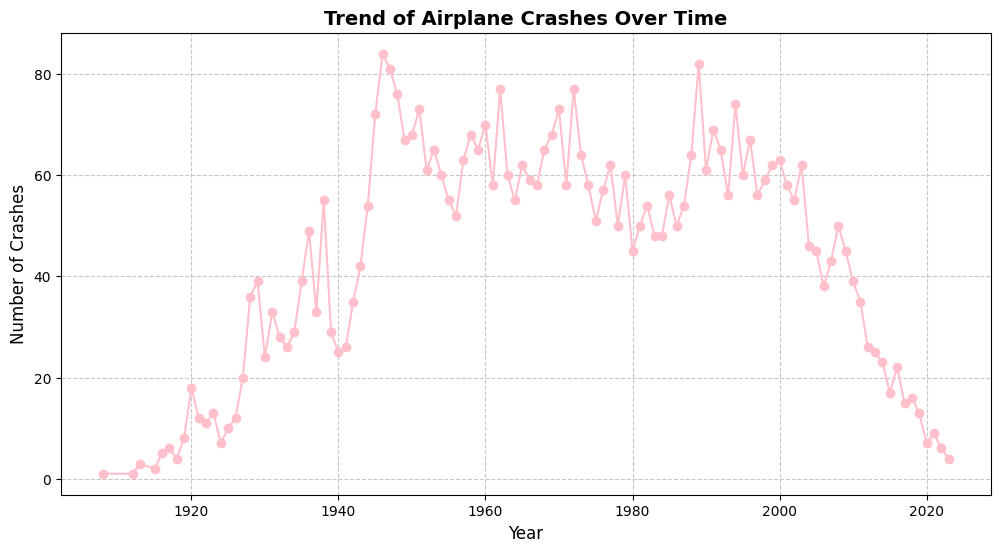

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Line plot
plt.plot(crashes_per_year["Year"], crashes_per_year["Crash Count"], color='pink', marker='o', linestyle='-')

# Labels and title
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Crashes", fontsize=12)
plt.title("Trend of Airplane Crashes Over Time", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.7)

plt.show()


**Statistical Analysis:**

- Apply SciPy to analyze the distribution of fatalities and survival rates. Calculate key statistics like mean, median, and standard deviation.

In [ ]:
import scipy.stats as stats
import numpy as np

fatalities = airplane_crashes["Fatalities"].dropna()
survival_rate = airplane_crashes["Survival Rate"].dropna()

# Calculate mean, median, and standard deviation for fatalities
fatalities_mean = stats.tmean(fatalities)
fatalities_median = np.median(fatalities)
fatalities_std = stats.tstd(fatalities)

print(f"Mean of Fatalities: {fatalities_mean}")
print(f"Median of Fatalities: {fatalities_median}")
print(f"Standard Deviation of Fatalities: {fatalities_std}")

# Calculate mean, median, and standard deviation for survival rate
survival_rate_mean = stats.tmean(survival_rate)
survival_rate_median = np.median(survival_rate)
survival_rate_std = stats.tstd(survival_rate)

print(f"\nMean of Survival Rate: {survival_rate_mean}")
print(f"Median of Survival Rate: {survival_rate_median}")
print(f"Standard Deviation of Survival Rate: {survival_rate_std}")


Mean of Fatalities: 22.530127814972612
Median of Fatalities: 11.0
Standard Deviation of Fatalities: 35.229349943002774

Mean of Survival Rate: 18.204766817272755
Median of Survival Rate: 0.0
Standard Deviation of Survival Rate: 31.249147261781587


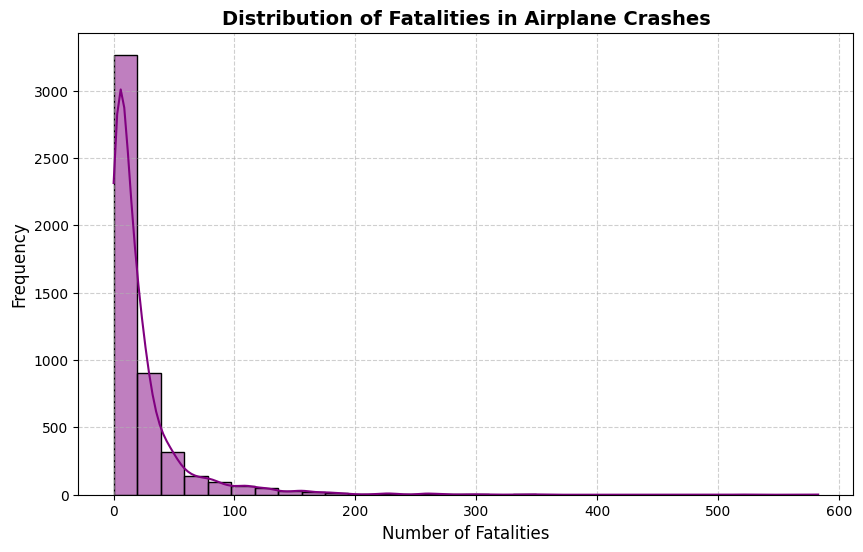

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(airplane_crashes["Fatalities"], bins=30, kde=True, color="purple")

plt.title("Distribution of Fatalities in Airplane Crashes", fontsize=14, fontweight="bold")
plt.xlabel("Number of Fatalities", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


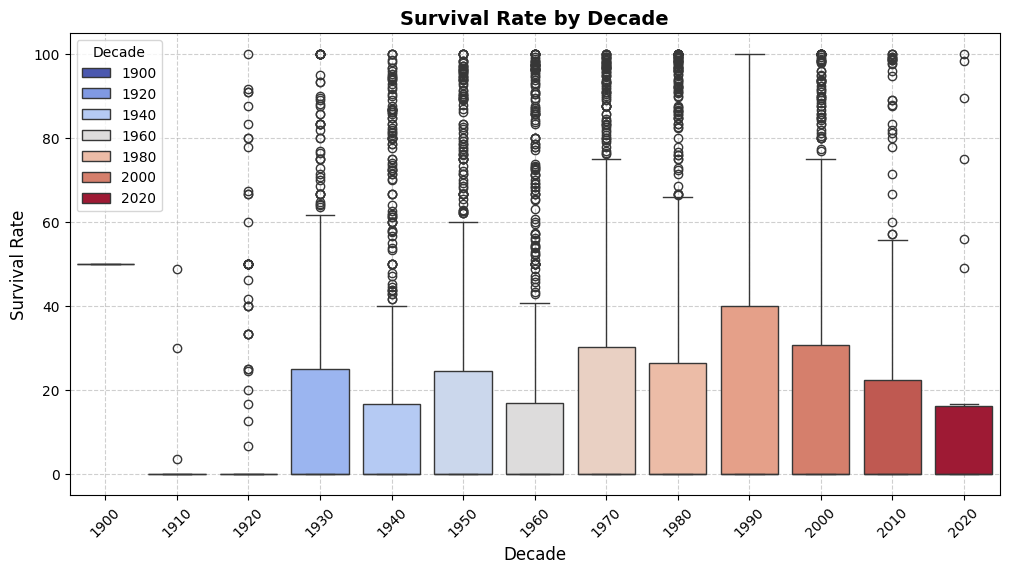

In [ ]:
# Extract decade from Date column
airplane_crashes["Decade"] = (airplane_crashes["Date"].dt.year // 10) * 10 # ex : 1965//10 → 196 and 196*10 → 1960

plt.figure(figsize=(12, 6))
sns.boxplot(x="Decade", y="Survival Rate", hue="Decade", data=airplane_crashes, palette="coolwarm")

plt.title("Survival Rate by Decade", fontsize=14, fontweight="bold")
plt.xlabel("Decade", fontsize=12)
plt.ylabel("Survival Rate", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


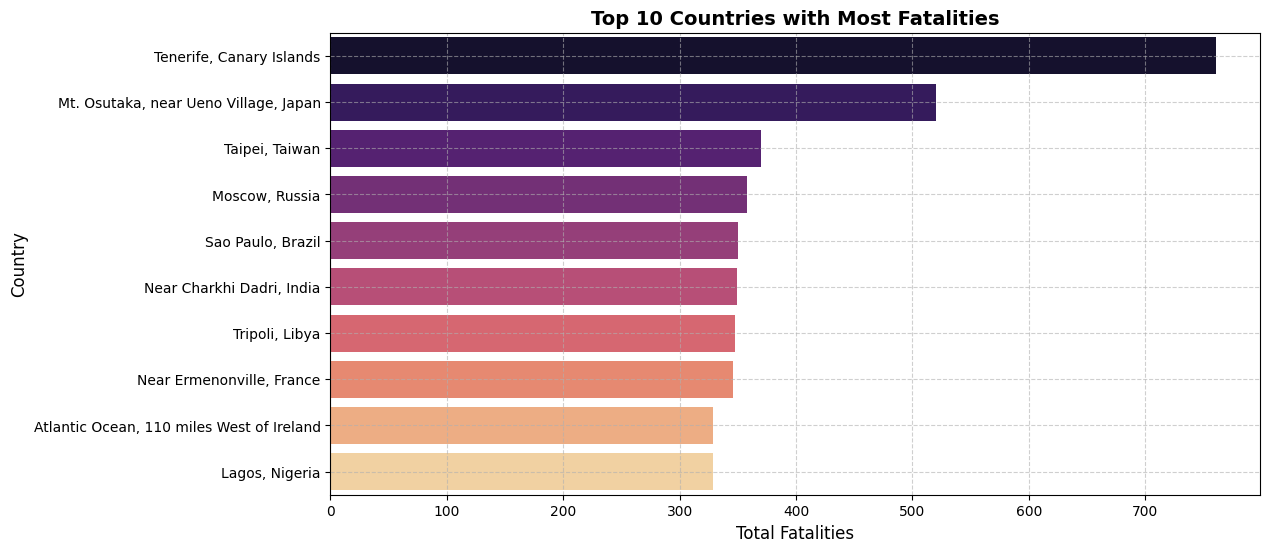

In [ ]:
fatalities_per_location = airplane_crashes.groupby("Location")["Fatalities"].sum().nlargest(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=fatalities_per_location.values, y=fatalities_per_location.index, hue=fatalities_per_location.index, palette="magma")

plt.title("Top 10 Countries with Most Fatalities", fontsize=14, fontweight="bold")
plt.xlabel("Total Fatalities", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


- Conduct a hypothesis test (e.g., comparing the average number of fatalities in different decades or regions).

In [ ]:
# Select two decades for comparison: 1970s vs. 2000s
fatalities_1970s = airplane_crashes[airplane_crashes["Decade"] == 1970]["Fatalities"]
fatalities_2000s = airplane_crashes[airplane_crashes["Decade"] == 2000]["Fatalities"]

t_stat, p_value = stats.ttest_ind(fatalities_1970s, fatalities_2000s)
print(f"T-test results:\nT-statistic = {t_stat:.4f}, P-value = {p_value:.4f}")

T-test results:
T-statistic = 3.9314, P-value = 0.0001


p-value = 0.0001 < 0.05 --> Reject the null hypothesis. There is a significant difference in fatalities between the 1970s and 2000s.

**Visualization:**

Inside the previous answers.

**Insight and Report:**

1. **General Overview**
 - The dataset contains 4,998 recorded airplane crashes spanning from 1908 to 2023.
 - A total of Fatalities and Survival Rates were analyzed across different decades and locations.

2. **Trends over Time**
 - The number of airplane crashes peaked between the 1940s and 1980s, with a gradual decline in recent decades.
 - This decline after 2000 suggests improved aviation safety regulations, better aircraft technology, and stricter operational guidelines.

3. **Fatalities & Survival Rate Analysis**
 - The mean number of fatalities per crash is approximately 22.5, with a median of 11, indicating that while some crashes had high casualties, many had fewer deaths.

4. **Geographic Patterns**
 - Certain locations have recorded more crashes and fatalities than others.
 - A few countries and regions show abnormally high numbers of incidents, which could be due to:
    - High air traffic volume
    - Challenging weather conditions
    - Older aircraft fleets
    - Weaker aviation regulations in some regions
*Insight:* Some countries may require stricter aviation safety enforcement and improvements in pilot training and air traffic control systems.

5. **Hypothesis Test: Did Fatalities Decrease Over Time?**
 - A t-test comparing the 1970s and 2000s showed a statistically significant decrease in fatalities in more recent years.
 - This supports the hypothesis that modern aviation is safer than in the past.

**Conclusion:**
The aviation industry has made significant safety advancements, reducing the number of crashes and fatalities. However, certain locations still exhibit higher accident rates, and further investigation into their causes could help prevent future incidents.